# **Heat Map Python**

In [ ]:
#Importar Liberias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Explicación del Dataset
El Dataset consiste básicamente en datos sobre dolores de una persona de acuerdo a su altura, sexo, edad y peso.

*   Los datos de la escala de dolor
*   Altura del participante en pulgadas
*   Peso del participante en libras




In [ ]:
#Cargar Dataset
df = pd.read_csv("/content/drive/MyDrive/Curso Estadistica con Python/DatasetHeatMap.csv")
df2 = df[['AGE', 'HEIGHT',"WEIGHT","SEX","PAIN 1","PAIN 2","PAIN 3","PAIN 4"]]
dfDolor =df2.rename(columns={"AGE":"EDAD","HEIGHT":"ALTURA","WEIGHT":"PESO","SEX":"SEXO","PAIN 1":"DOLOR CUELLO","PAIN 2":"DOLOR TORAX","PAIN 3":"DOLOR LUMBAR","PAIN 4":"DOLOR SACRO"})
dfDolor['SEXO'] = dfDolor['SEXO'].astype(object)
dfDolor.loc[df.SEX=="Male","SEXO"] ="Hombres"
dfDolor.loc[df.SEX=="Female","SEXO"] ="Mujeres"
dfDolor

,EDAD,ALTURA,PESO,SEXO,DOLOR CUELLO,DOLOR TORAX,DOLOR LUMBAR,DOLOR SACRO
0,53,62,125,0,55.3,37.2,32.00,66.7
1,52,69,157,1,75.0,51.4,41.55,81.2
2,30,69,200,1,83.0,43.4,37.50,86.7
3,51,66,175,1,84.6,51.1,48.50,84.0
4,45,63,199,0,88.1,42.8,43.10,89.6
...,...,...,...,...,...,...,...,...
92,16,58,100,1,41.6,36.8,19.00,53.6
93,45,62,134,0,58.1,41.2,31.35,67.8
94,43,69,188,1,81.5,43.4,38.95,85.7
95,28,67,180,0,74.8,40.2,34.00,79.7


In [ ]:
#Correlación lineal
corr = dfDolor.corr()
print(corr)

                  EDAD    ALTURA      PESO      SEXO  DOLOR CUELLO  \
EDAD          1.000000 -0.029032  0.272758  0.051802      0.377467   
ALTURA       -0.029032  1.000000  0.550871  0.542725      0.499406   
PESO          0.272758  0.550871  1.000000  0.506899      0.978740   
SEXO          0.051802  0.542725  0.506899  1.000000      0.459518   
DOLOR CUELLO  0.377467  0.499406  0.978740  0.459518      1.000000   
DOLOR TORAX   0.020686  0.708707  0.457213  0.511019      0.445382   
DOLOR LUMBAR  0.675475  0.375190  0.828114  0.365001      0.891367   
DOLOR SACRO   0.506522  0.487094  0.942459  0.451153      0.962638   

              DOLOR TORAX  DOLOR LUMBAR  DOLOR SACRO  
EDAD             0.020686      0.675475     0.506522  
ALTURA           0.708707      0.375190     0.487094  
PESO             0.457213      0.828114     0.942459  
SEXO             0.511019      0.365001     0.451153  
DOLOR CUELLO     0.445382      0.891367     0.962638  
DOLOR TORAX      1.000000      0.408195

In [ ]:
corr_matrix_kendall = dfDolor.corr(method='kendall')
corr_matrix_spearman = dfDolor.corr(method='spearman')


# **Gráficos con Seaborn**

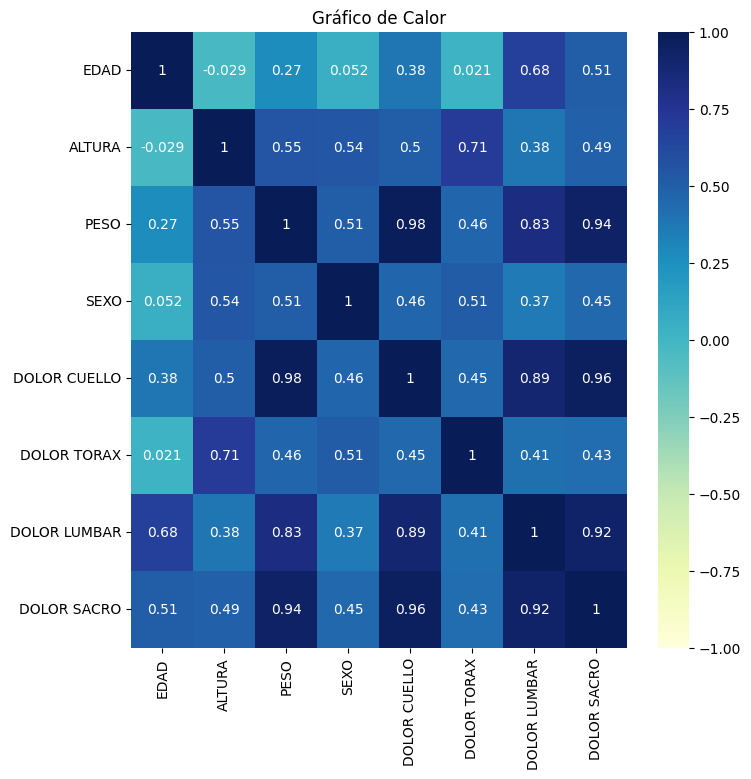

In [ ]:
#Gráfico más detallado
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, annot=True, cmap='YlGnBu', vmax=1,vmin=-1)
plt.title('Gráfico de Calor')
plt.show()

# **Gráficos con Matplotlib**

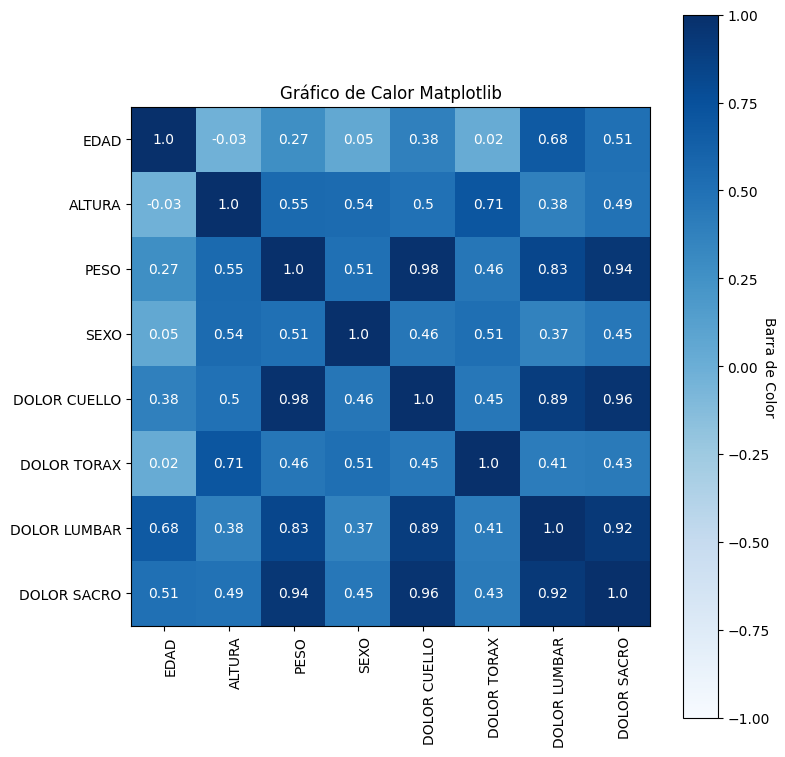

In [ ]:
#Gráfico más detallado

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(corr,vmin=-1, vmax=1,cmap="Blues")
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Barra de Color", rotation = -90)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))

ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)

plt.setp(ax.get_xticklabels(), rotation=90, ha="right",
         rotation_mode="anchor")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        text = ax.text(j, i, round(corr.iloc[i, j],2),
                       ha="center", va="center", color= "w")

ax.set_title("Gráfico de Calor Matplotlib")
fig.tight_layout()
plt.show()